In [1]:
!pip install biopython scikit-learn pandas numpy matplotlib seaborn -q
print("Setup complete.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 9.8 MB/s eta 0:00:00
Setup complete.


In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from Bio import Entrez
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    confusion_matrix, accuracy_score, roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score, average_precision_score,
    precision_recall_curve
)
from sklearn.feature_extraction.text import CountVectorizer

RANDOM_SEED   = 42
WINDOW_SIZE   = 50
MAX_KMERS     = 256
N_TREES       = 200          # matches manuscript Section 2.4 exactly — not tuned
ENTREZ_EMAIL  = "bilalzaib.microbio@gmail.com"

DOMAINS = {
    'TAD1':       (1,   40),
    'TAD2':       (41,  67),
    'Proline':    (68,  101),
    'DBD':        (102, 292),
    'Linker':     (293, 324),
    'Tetra':      (325, 356),
    'Regulatory': (357, 393),
}
HOTSPOT_CODONS = {175, 245, 248, 249, 273, 282}

# GRCh38 genomic boundaries of TP53 (NC_000017.11), as already verified
# consistently throughout this project
TP53_START = 7661779
TP53_END   = 7687538
FETCH_PAD  = 200   # extra bases fetched on each side so edge variants still get a full window

print("Constants locked.")

Constants locked.


In [3]:
def get_domain(codon_number):
    for name, (start, end) in DOMAINS.items():
        if start <= codon_number <= end:
            return name
    return 'Unknown'

def get_first_codon(protein_change):
    if pd.isna(protein_change):
        return None
    first_entry = str(protein_change).split(',')[0].strip()
    match = re.search(r'(\d+)', first_entry)
    return int(match.group(1)) if match else None

def parse_spdi(spdi_string):
    try:
        parts = str(spdi_string).split(':')
        position = int(parts[1])   # 0-based, per SPDI spec
        return position, parts[2], parts[3]
    except Exception:
        return None, None, None

def is_transition(ref_base, alt_base):
    if ref_base is None or alt_base is None:
        return -1
    transitions = {('A','G'), ('G','A'), ('C','T'), ('T','C')}
    return 1 if (ref_base, alt_base) in transitions else 0

def extract_genomic_window(genomic_seq, idx_in_seq, window=WINDOW_SIZE):
    start = max(0, idx_in_seq - window)
    end = min(len(genomic_seq), idx_in_seq + window + 1)
    return genomic_seq[start:end]

print("Helper functions defined. No proportional estimation anywhere in this version.")

Helper functions defined. No proportional estimation anywhere in this version.


In [4]:
print("Fetching TP53 genomic region from NCBI (NC_000017.11)...")
Entrez.email = ENTREZ_EMAIL

fetch_start = TP53_START - FETCH_PAD   # 1-based, NCBI convention
fetch_end   = TP53_END + FETCH_PAD

handle = Entrez.efetch(
    db="nucleotide",
    id="NC_000017.11",
    rettype="fasta",
    retmode="text",
    seq_start=fetch_start,
    seq_stop=fetch_end
)
from Bio import SeqIO
genomic_record = SeqIO.read(handle, "fasta")
handle.close()

genomic_seq = str(genomic_record.seq).upper()
print(f"Genomic region fetched: {len(genomic_seq)} bp (expected approx {fetch_end - fetch_start + 1})")

def genomic_pos_to_index(spdi_pos_0based):
    # spdi_pos is 0-based genomic coordinate; fetch_start is 1-based
    return spdi_pos_0based - (fetch_start - 1)

Fetching TP53 genomic region from NCBI (NC_000017.11)...
Genomic region fetched: 26160 bp (expected approx 26160)


In [6]:
print("Loading ClinVar data...")
df_raw = pd.read_csv('/content/clinvar_result.txt', sep='\t', low_memory=False)
print(f"Raw rows: {len(df_raw)}")

keep_labels = [
    'Pathogenic', 'Likely pathogenic', 'Pathogenic/Likely pathogenic',
    'Pathogenic/Likely pathogenic/Pathogenic, low penetrance',
    'Benign', 'Likely benign', 'Likely benign/Benign', 'Benign/Likely benign'
]
df_raw_filtered = df_raw[df_raw['Germline classification'].isin(keep_labels)].reset_index(drop=True)
print(f"After VUS/conflicting exclusion: {len(df_raw_filtered)} (expect 1470)")

pathogenic_set = {'Pathogenic', 'Likely pathogenic', 'Pathogenic/Likely pathogenic',
                   'Pathogenic/Likely pathogenic/Pathogenic, low penetrance'}

records = []
excluded_spdi_fail = 0
excluded_refbase_mismatch = 0
excluded_short_window = 0

for _, row in df_raw_filtered.iterrows():
    label = 1 if row['Germline classification'] in pathogenic_set else 0

    position, ref_base, alt_base = parse_spdi(row['Canonical SPDI'])
    if position is None:
        excluded_spdi_fail += 1
        continue

    idx = genomic_pos_to_index(position)
    if idx < 0 or idx >= len(genomic_seq):
        excluded_spdi_fail += 1
        continue

    # MANDATORY SANITY CHECK — this is the safeguard that was missing before
    actual_base = genomic_seq[idx]
    if actual_base != ref_base.upper():
        excluded_refbase_mismatch += 1
        continue

    dna_window = extract_genomic_window(genomic_seq, idx, WINDOW_SIZE)
    if len(dna_window) < 30:
        excluded_short_window += 1
        continue

    codon = get_first_codon(row['Protein change'])
    domain = get_domain(codon) if codon else 'Unknown'
    hotspot = int(codon in HOTSPOT_CODONS) if codon else 0
    rel_pos = (TP53_END - position) / (TP53_END - TP53_START)

    records.append({
        'sequence':      dna_window,
        'label':         label,
        'codon':         codon if codon else 0,
        'rel_pos':       rel_pos,
        'domain':        domain,
        'is_hotspot':    hotspot,
        'is_transition': is_transition(ref_base, alt_base),
        'ref_base':      ref_base,
        'alt_base':      alt_base
    })

df = pd.DataFrame(records)

print(f"\n===== INTEGRITY REPORT =====")
print(f"SPDI parse / out-of-range failures: {excluded_spdi_fail}")
print(f"REF BASE MISMATCHES (coordinate math errors, excluded): {excluded_refbase_mismatch}")
print(f"Short window failures: {excluded_short_window}")
print(f"Final dataset: {len(df)} variants")
print(f"Pathogenic: {(df['label']==1).sum()} | Benign: {(df['label']==0).sum()}")
print(f"Domain breakdown:\n{df['domain'].value_counts()}")
print("=============================")
print("\nIf excluded_refbase_mismatch is more than a handful, STOP — the coordinate")
print("offset math is wrong and must be fixed before continuing.")

Loading ClinVar data...
Raw rows: 2739
After VUS/conflicting exclusion: 1470 (expect 1470)

===== INTEGRITY REPORT =====
SPDI parse / out-of-range failures: 1
REF BASE MISMATCHES (coordinate math errors, excluded): 0
Short window failures: 0
Final dataset: 1469 variants
Pathogenic: 410 | Benign: 1059
Domain breakdown:
domain
Unknown       992
DBD           388
TAD1           43
TAD2           18
Proline        17
Tetra           6
Linker          4
Regulatory      1
Name: count, dtype: int64

If excluded_refbase_mismatch is more than a handful, STOP — the coordinate
offset math is wrong and must be fixed before continuing.


In [7]:
kmer_vectorizer = CountVectorizer(analyzer='char', ngram_range=(3, 4), max_features=MAX_KMERS)
X_kmers = kmer_vectorizer.fit_transform(df['sequence']).toarray()

X_biological = df[['codon', 'rel_pos', 'is_hotspot', 'is_transition']].values
ref_encoded = pd.get_dummies(df['ref_base'], prefix='ref')
alt_encoded = pd.get_dummies(df['alt_base'], prefix='alt')
dom_encoded = pd.get_dummies(df['domain'], prefix='dom')

X = np.hstack([
    X_kmers, X_biological,
    ref_encoded.astype(float).values,
    alt_encoded.astype(float).values,
    dom_encoded.astype(float).values
])
y = df['label'].values

feature_names = (
    list(kmer_vectorizer.get_feature_names_out()) +
    ['codon_pos', 'rel_pos', 'is_hotspot', 'is_transition'] +
    list(ref_encoded.columns) + list(alt_encoded.columns) + list(dom_encoded.columns)
)

print(f"Feature matrix: {X.shape[0]} samples x {X.shape[1]} features")

Feature matrix: 1469 samples x 276 features


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Test set — Pathogenic: {(y_test==1).sum()} | Benign: {(y_test==0).sum()}")
print("Compare this to the previously verified 82 pathogenic / 212 benign.")
print("If these don't match, the CADD and dbNSFP benchmark notebooks are NOT compatible")
print("with this run and must be re-verified before reuse.\n")

model = RandomForestClassifier(
    n_estimators=N_TREES, min_samples_split=3,
    class_weight='balanced', random_state=RANDOM_SEED
)
model.fit(X_train, y_train)

y_pred_proba = model.predict_proba(X_test)[:, 1]
y_predictions = model.predict(X_test)

cv_scores = cross_val_score(model, X_train, y_train, cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_SEED), scoring='roc_auc')
print(f"5-fold CV AUC: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")

Train: 1175 | Test: 294
Test set — Pathogenic: 82 | Benign: 212
Compare this to the previously verified 82 pathogenic / 212 benign.
If these don't match, the CADD and dbNSFP benchmark notebooks are NOT compatible
with this run and must be re-verified before reuse.

5-fold CV AUC: 0.9609 +/- 0.0166


In [9]:
auc_roc = roc_auc_score(y_test, y_pred_proba)
auprc = average_precision_score(y_test, y_pred_proba)
accuracy = accuracy_score(y_test, y_predictions)
recall = recall_score(y_test, y_predictions)          # sensitivity
precision = precision_score(y_test, y_predictions)    # PPV
f1 = f1_score(y_test, y_predictions)

tn, fp, fn, tp = confusion_matrix(y_test, y_predictions).ravel()
spec = tn / (tn + fp)
npv = tn / (tn + fn)

print("===== RESULTS — VERIFY AGAINST MANUSCRIPT BEFORE USING =====")
print(f"AUC-ROC      : {auc_roc:.4f}")
print(f"AUPRC        : {auprc:.4f}")
print(f"Accuracy     : {accuracy:.4f}")
print(f"Sensitivity  : {recall:.4f}")
print(f"Specificity  : {spec:.4f}")
print(f"PPV          : {precision:.4f}")
print(f"NPV          : {npv:.4f}")
print(f"F1           : {f1:.4f}")
print(f"Confusion: TN={tn} FP={fp} FN={fn} TP={tp}")
print("==============================================================")

===== RESULTS — VERIFY AGAINST MANUSCRIPT BEFORE USING =====
AUC-ROC      : 0.9478
AUPRC        : 0.8692
Accuracy     : 0.9184
Sensitivity  : 0.8780
Specificity  : 0.9340
PPV          : 0.8372
NPV          : 0.9519
F1           : 0.8571
Confusion: TN=198 FP=14 FN=10 TP=72


In [13]:
rng = np.random.RandomState(42)
y_test_arr = np.asarray(y_test)
y_pred_proba_arr = np.asarray(y_pred_proba)

aucs, senss, specs = [], [], []
for _ in range(n_bootstrap):
    idx = rng.choice(len(y_test_arr), size=len(y_test_arr), replace=True)
    y_t, y_s = y_test_arr[idx], y_pred_proba_arr[idx]
    if len(np.unique(y_t)) < 2:
        continue
    aucs.append(roc_auc_score(y_t, y_s))
    y_p = (y_s >= 0.5).astype(int)
    tn_, fp_, fn_, tp_ = confusion_matrix(y_t, y_p).ravel()
    senss.append(tp_/(tp_+fn_) if (tp_+fn_) > 0 else np.nan)
    specs.append(tn_/(tn_+fp_) if (tn_+fp_) > 0 else np.nan)

print(f"AUC-ROC: {np.mean(aucs):.4f} (95% CI: {np.percentile(aucs,2.5):.4f}-{np.percentile(aucs,97.5):.4f})")
print(f"Sensitivity: {np.nanmean(senss):.4f} (95% CI: {np.nanpercentile(senss,2.5):.4f}-{np.nanpercentile(senss,97.5):.4f})")
print(f"Specificity: {np.nanmean(specs):.4f} (95% CI: {np.nanpercentile(specs,2.5):.4f}-{np.nanpercentile(specs,97.5):.4f})")

AUC-ROC: 0.9476 (95% CI: 0.9164-0.9724)
Sensitivity: 0.8775 (95% CI: 0.8056-0.9445)
Specificity: 0.9336 (95% CI: 0.9009-0.9646)


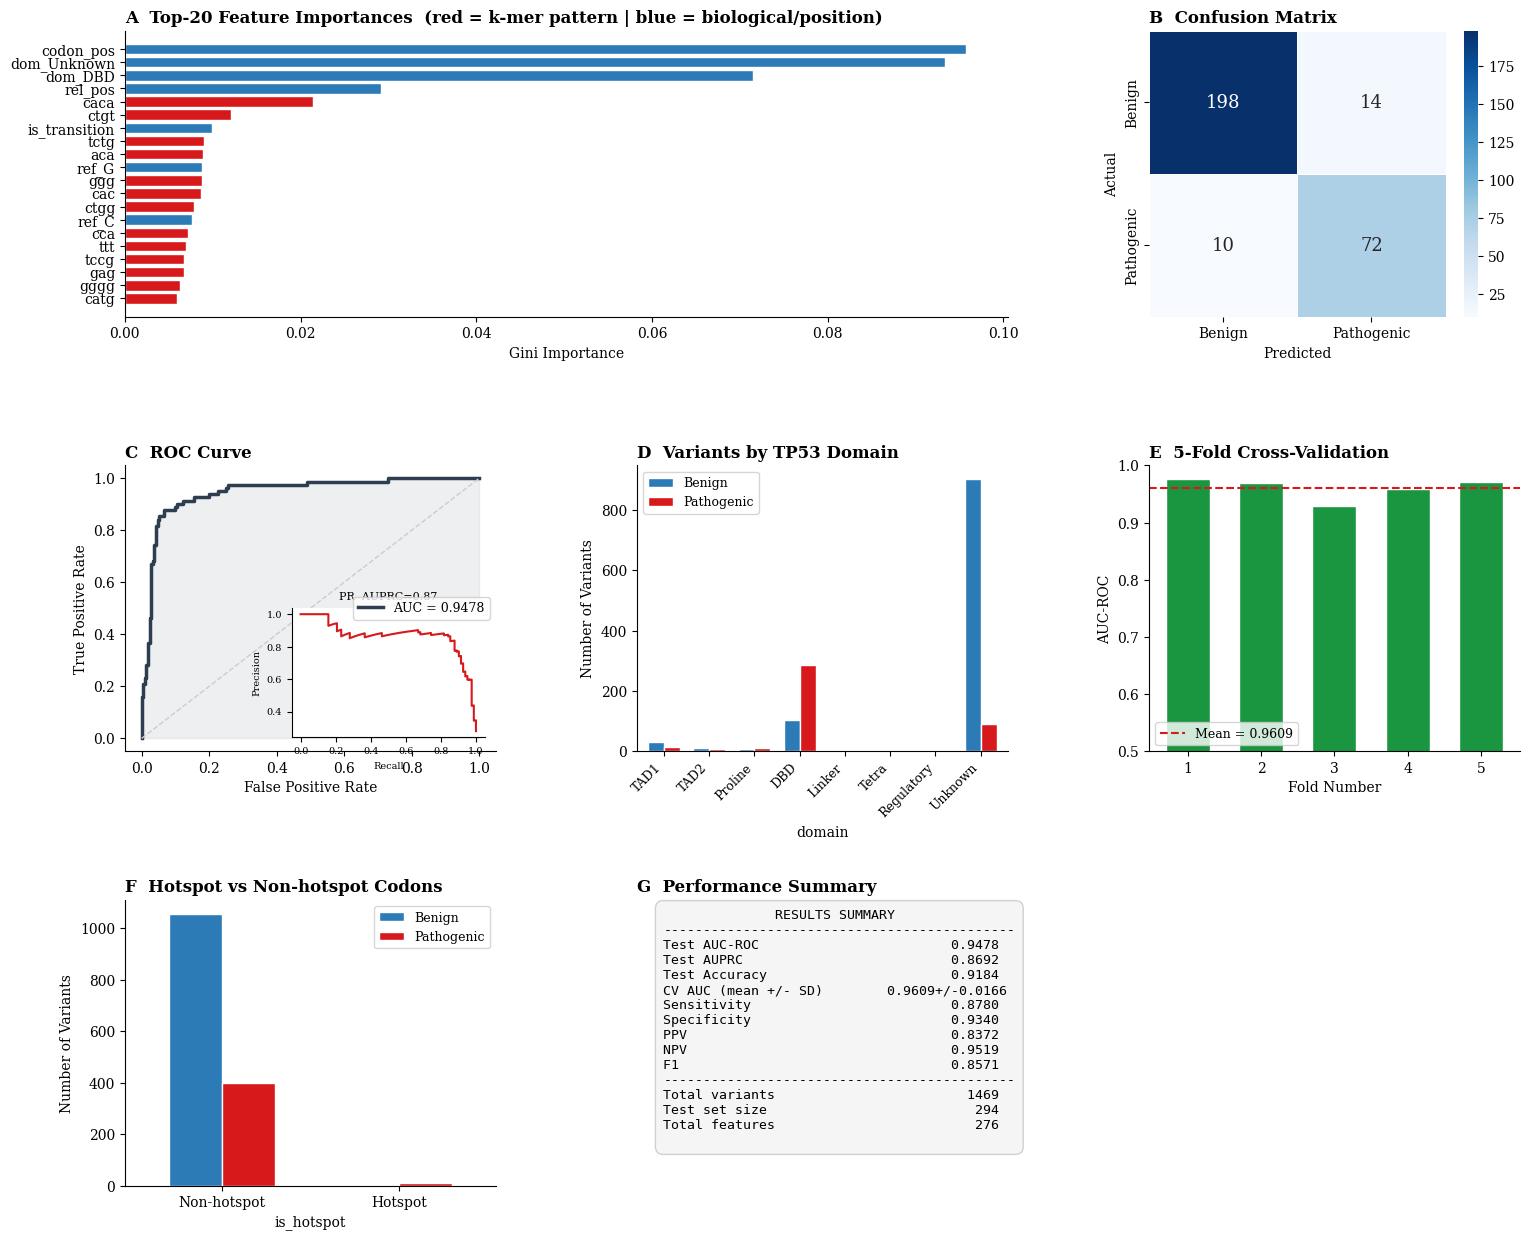

In [14]:
plt.rcParams.update({'font.family': 'serif', 'font.size': 10,
                      'axes.spines.top': False, 'axes.spines.right': False})
BLUE, RED, GREEN = '#2c7bb6', '#d7191c', '#1a9641'

fig = plt.figure(figsize=(18, 15))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.52, wspace=0.38)

ax_a = fig.add_subplot(gs[0, :2])
importance_df = pd.DataFrame({'feature': feature_names, 'importance': model.feature_importances_}).nlargest(20, 'importance')
bio_feats = {'codon_pos','rel_pos','is_hotspot','is_transition'}
colors = [BLUE if (f.startswith(('dom_','ref_','alt_')) or f in bio_feats) else RED for f in importance_df['feature']]
ax_a.barh(importance_df['feature'], importance_df['importance'], color=colors, edgecolor='white')
ax_a.invert_yaxis()
ax_a.set_xlabel('Gini Importance')
ax_a.set_title('A  Top-20 Feature Importances  (red = k-mer pattern | blue = biological/position)', loc='left', fontweight='bold')

ax_b = fig.add_subplot(gs[0, 2])
cm = confusion_matrix(y_test, y_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax_b, xticklabels=['Benign','Pathogenic'], yticklabels=['Benign','Pathogenic'], annot_kws={'size':13}, linewidths=0.5)
ax_b.set_xlabel('Predicted'); ax_b.set_ylabel('Actual')
ax_b.set_title('B  Confusion Matrix', loc='left', fontweight='bold')

ax_c = fig.add_subplot(gs[1, 0])
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
ax_c.plot(fpr, tpr, color='#2c3e50', lw=2.5, label=f'AUC = {auc_roc:.4f}')
ax_c.fill_between(fpr, tpr, alpha=0.08, color='#2c3e50')
ax_c.plot([0,1],[0,1],'--', color='#cccccc', lw=1)
ax_c.set_xlabel('False Positive Rate'); ax_c.set_ylabel('True Positive Rate')
ax_c.set_title('C  ROC Curve', loc='left', fontweight='bold')
ax_c.legend(fontsize=9)
ax_ins = ax_c.inset_axes([0.45,0.05,0.52,0.45])
pr_p, pr_r, _ = precision_recall_curve(y_test, y_pred_proba)
ax_ins.plot(pr_r, pr_p, color=RED, lw=1.5)
ax_ins.set_title(f'PR  AUPRC={auprc:.2f}', fontsize=8)
ax_ins.set_xlabel('Recall', fontsize=7); ax_ins.set_ylabel('Precision', fontsize=7); ax_ins.tick_params(labelsize=7)

ax_d = fig.add_subplot(gs[1, 1])
domain_order = [d for d in list(DOMAINS.keys())+['Unknown'] if d in df['domain'].unique()]
domain_table = df.groupby(['domain','label']).size().unstack(fill_value=0).rename(columns={0:'Benign',1:'Pathogenic'}).reindex(domain_order)
domain_table.plot(kind='bar', ax=ax_d, color=[BLUE,RED], edgecolor='white', width=0.7)
ax_d.set_xticklabels(ax_d.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax_d.set_ylabel('Number of Variants')
ax_d.set_title('D  Variants by TP53 Domain', loc='left', fontweight='bold')
ax_d.legend(fontsize=9)

ax_e = fig.add_subplot(gs[1, 2])
ax_e.bar(range(1,6), cv_scores, color=GREEN, edgecolor='white', width=0.6)
ax_e.axhline(cv_scores.mean(), color=RED, linestyle='--', lw=1.5, label=f'Mean = {cv_scores.mean():.4f}')
ax_e.set_xlabel('Fold Number'); ax_e.set_ylabel('AUC-ROC'); ax_e.set_ylim(0.5,1.0)
ax_e.set_title('E  5-Fold Cross-Validation', loc='left', fontweight='bold')
ax_e.legend(fontsize=9)

ax_f = fig.add_subplot(gs[2, 0])
hotspot_table = df.groupby(['is_hotspot','label']).size().unstack(fill_value=0).rename(columns={0:'Benign',1:'Pathogenic'}).rename(index={0:'Non-hotspot',1:'Hotspot'})
hotspot_table.plot(kind='bar', ax=ax_f, color=[BLUE,RED], edgecolor='white', width=0.6)
ax_f.set_xticklabels(ax_f.get_xticklabels(), rotation=0)
ax_f.set_ylabel('Number of Variants')
ax_f.set_title('F  Hotspot vs Non-hotspot Codons', loc='left', fontweight='bold')
ax_f.legend(fontsize=9)

ax_g = fig.add_subplot(gs[2, 1:])
ax_g.axis('off')
summary = (f"{'RESULTS SUMMARY':^44}\n{'-'*44}\n"
           f"{'Test AUC-ROC':<28}{auc_roc:>14.4f}\n{'Test AUPRC':<28}{auprc:>14.4f}\n"
           f"{'Test Accuracy':<28}{accuracy:>14.4f}\n{'CV AUC (mean +/- SD)':<28}{cv_scores.mean():.4f}+/-{cv_scores.std():.4f}\n"
           f"{'Sensitivity':<28}{recall:>14.4f}\n{'Specificity':<28}{spec:>14.4f}\n"
           f"{'PPV':<28}{precision:>14.4f}\n{'NPV':<28}{npv:>14.4f}\n{'F1':<28}{f1:>14.4f}\n"
           f"{'-'*44}\n{'Total variants':<28}{len(df):>14}\n{'Test set size':<28}{len(X_test):>14}\n"
           f"{'Total features':<28}{X.shape[1]:>14}\n")
ax_g.text(0.03, 0.97, summary, transform=ax_g.transAxes, fontsize=9.5, va='top', fontfamily='monospace',
          bbox=dict(boxstyle='round,pad=0.6', facecolor='#f4f4f4', edgecolor='#cccccc', alpha=0.9))
ax_g.set_title('G  Performance Summary', loc='left', fontweight='bold')

plt.savefig('Figure1_TP53_RF.png', dpi=300, bbox_inches='tight')
plt.show()

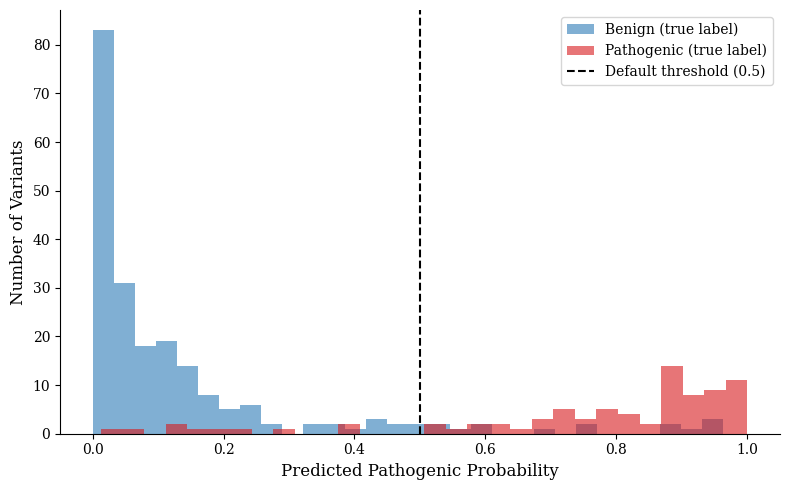

In [15]:
plt.figure(figsize=(8,5))
plt.hist(y_pred_proba[y_test==0], bins=30, alpha=0.6, color=BLUE, label='Benign (true label)')
plt.hist(y_pred_proba[y_test==1], bins=30, alpha=0.6, color=RED, label='Pathogenic (true label)')
plt.axvline(0.5, color='black', linestyle='--', lw=1.5, label='Default threshold (0.5)')
plt.xlabel('Predicted Pathogenic Probability', fontsize=12)
plt.ylabel('Number of Variants', fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.savefig('Figure2_probability_dist.png', dpi=300, bbox_inches='tight')
plt.show()

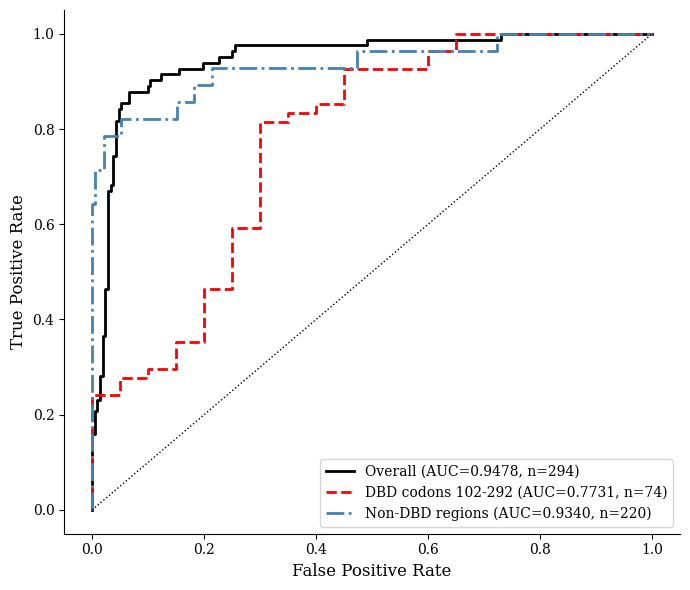

In [16]:
_, X_test_df_idx, _, _ = train_test_split(df, df['label'], test_size=0.2, random_state=RANDOM_SEED, stratify=df['label'])
test_codons = df.loc[X_test_df_idx.index, 'codon'].values
dbd_mask = (test_codons >= 102) & (test_codons <= 292)
non_dbd_mask = ~dbd_mask

fpr_all, tpr_all, _ = roc_curve(y_test, y_pred_proba)
fpr_dbd, tpr_dbd, _ = roc_curve(y_test[dbd_mask], y_pred_proba[dbd_mask])
fpr_non, tpr_non, _ = roc_curve(y_test[non_dbd_mask], y_pred_proba[non_dbd_mask])
auc_dbd = roc_auc_score(y_test[dbd_mask], y_pred_proba[dbd_mask])
auc_non = roc_auc_score(y_test[non_dbd_mask], y_pred_proba[non_dbd_mask])

fig, ax = plt.subplots(figsize=(7,6))
ax.plot(fpr_all, tpr_all, color='black', lw=2, label=f'Overall (AUC={auc_roc:.4f}, n={len(y_test)})')
ax.plot(fpr_dbd, tpr_dbd, color='red', lw=2, linestyle='--', label=f'DBD codons 102-292 (AUC={auc_dbd:.4f}, n={dbd_mask.sum()})')
ax.plot(fpr_non, tpr_non, color='steelblue', lw=2, linestyle='-.', label=f'Non-DBD regions (AUC={auc_non:.4f}, n={non_dbd_mask.sum()})')
ax.plot([0,1],[0,1],'k:', lw=1)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig('Figure3_DBD_stratified.png', dpi=300, bbox_inches='tight')
plt.show()